# Model 1 — Lap Time Regression / Prediction

This notebook is focused on **predicting lap time**. The workflow covers data preparation, feature engineering, train/test splitting, regression modelling, evaluation, and prediction diagnostics.


In [2]:
# pip install fastf1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

In [4]:
# Enabling the Cache...
import os

# Create a folder named 'cache' in your current directory
if not os.path.exists('cache'):
    os.makedirs('cache')

# Enable the cache
fastf1.Cache.enable_cache('cache')

In [5]:
session = fastf1.get_session(2026, 'Barcelona', 'R')
session.load()

core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['44', '63', '1', '3', '81', '6', '10', '30', '41', '43', '5', '55', '31', '11', '16', '12', '87', '2

In [6]:
hamilton = session.laps.pick_driver('HAM')
fastestLap = hamilton.pick_fastest()

print(fastestLap)

Time                      0 days 01:55:27.997000
Driver                                       HAM
DriverNumber                                  44
LapTime                   0 days 00:01:20.122000
LapNumber                                   44.0
Stint                                        4.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:23.533000
Sector2Time               0 days 00:00:32.255000
Sector3Time               0 days 00:00:24.334000
Sector1SessionTime        0 days 01:54:31.453000
Sector2SessionTime        0 days 01:55:03.708000
Sector3SessionTime        0 days 01:55:28.042000
SpeedI1                                    258.0
SpeedI2                                    268.0
SpeedFL                                    297.0
SpeedST                                    321.0
IsPersonalBest                              True
Compound                                    HARD
TyreLife            

/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [7]:
telemetry = fastestLap.get_telemetry()

print(telemetry[['Distance', 'Speed', 'Throttle', 'Brake', 'nGear']].head(10))

      Distance       Speed  Throttle  Brake  nGear
2     0.001409  300.050001     100.0  False      7
3     4.282764  300.900002     100.0  False      7
4    20.016667  304.000000     100.0  False      8
5    28.039626  305.175002     100.0  False      8
6    45.262278  307.675002     100.0  False      8
7    61.350000  310.000000     100.0  False      8
8    67.756759  310.528572     100.0  False      8
9    85.616667  312.000000     100.0  False      8
10   92.045143  312.371860     100.0  False      8
11  102.918611  313.000000     100.0  False      8


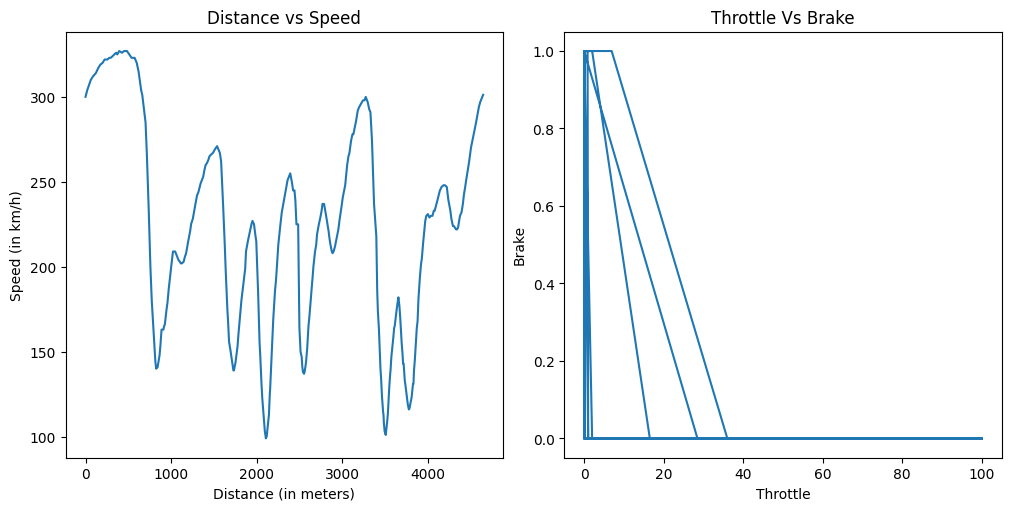

In [8]:
speed = telemetry['Speed']
dist = telemetry['Distance']
throttle = telemetry['Throttle']
brake = telemetry['Brake']

fig, ax = plt.subplots(1,2, figsize=(10,5), constrained_layout = True) # While constrained_layout works dynamically and better for complex layouts.

ax[0].plot(dist, speed)
ax[0].set_xlabel('Distance (in meters)')
ax[0].set_ylabel('Speed (in km/h)')
ax[0].set_title('Distance vs Speed')

ax[1].plot(throttle, brake)
ax[1].set_xlabel('Throttle')
ax[1].set_ylabel('Brake')
ax[1].set_title('Throttle Vs Brake')

# plt.tight_layout() #This is the same as constrained_layout, but it works after the graph have been created.
# plt.subplots_adjust(wspace = 0.4) # This is for the Horizontal spacing betweent the graphs...
plt.show()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

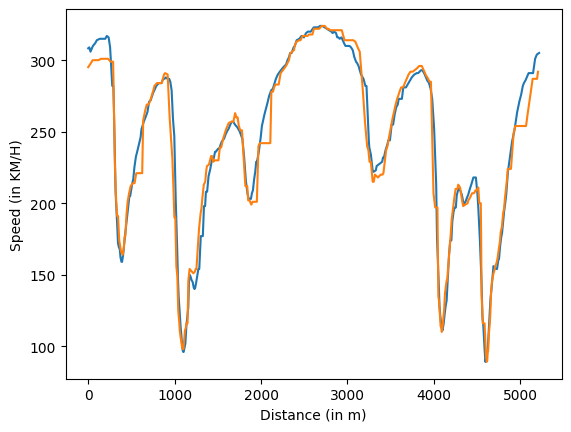

In [9]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fastf1 import plotting
plotting.setup_mpl()

session = fastf1.get_session(2026, 'Australia', 'R')
session.load(telemetry=True)

ham = session.laps.pick_drivers('HAM')
rus = session.laps.pick_drivers('RUS')

fastest_lap_ham = ham.pick_fastest()
fastest_lap_rus = rus.pick_fastest()


tele_ham = fastest_lap_ham.get_telemetry()
tele_rus = fastest_lap_rus.get_telemetry()


plt.plot(tele_ham['Distance'], tele_ham['Speed'])
plt.plot(tele_rus['Distance'],tele_rus['Speed'])
plt.xlabel("Distance (in m)")
plt.ylabel("Speed (in KM/H)")
plt.show()

In [10]:
results = session.results
print(results)

   DriverNumber BroadcastName Abbreviation        DriverId         TeamName  \
63           63     G RUSSELL          RUS         russell         Mercedes   
12           12   K ANTONELLI          ANT       antonelli         Mercedes   
16           16     C LECLERC          LEC         leclerc          Ferrari   
44           44    L HAMILTON          HAM        hamilton          Ferrari   
1             1      L NORRIS          NOR          norris          McLaren   
3             3  M VERSTAPPEN          VER  max_verstappen  Red Bull Racing   
87           87     O BEARMAN          BEA         bearman     Haas F1 Team   
41           41    A LINDBLAD          LIN  arvid_lindblad     Racing Bulls   
5             5   G BORTOLETO          BOR       bortoleto             Audi   
10           10       P GASLY          GAS           gasly           Alpine   
31           31        E OCON          OCO            ocon     Haas F1 Team   
23           23       A ALBON          ALB          

In [11]:
weather = session.weather_data
print(weather)

                      Time  AirTemp  Humidity  Pressure  Rainfall  TrackTemp  \
0   0 days 00:00:13.466000     23.1      55.8    1013.7     False       36.2   
1   0 days 00:01:13.482000     23.2      55.1    1013.6     False       35.9   
2   0 days 00:02:13.483000     23.2      55.2    1013.6     False       35.6   
3   0 days 00:03:13.485000     23.1      55.7    1013.7     False       35.7   
4   0 days 00:04:13.518000     23.1      55.8    1013.8     False       35.8   
..                     ...      ...       ...       ...       ...        ...   
143 0 days 02:23:14.291000     25.2      51.9    1011.5     False       34.6   
144 0 days 02:24:14.277000     25.2      52.0    1011.5     False       34.4   
145 0 days 02:25:14.290000     25.1      51.7    1011.5     False       34.5   
146 0 days 02:26:14.290000     25.0      52.2    1011.5     False       34.3   
147 0 days 02:27:14.318000     25.0      52.7    1011.5     False       34.5   

     WindDirection  WindSpeed  
0      

In [12]:
compound = session.laps.pick_compounds("SOFT")
print(compound)

                      Time Driver DriverNumber                LapTime  \
158 0 days 02:09:38.047000    PER           11 0 days 00:01:33.422000   
159 0 days 02:11:04.361000    PER           11 0 days 00:01:26.314000   
160 0 days 02:12:32.456000    PER           11 0 days 00:01:28.095000   
161 0 days 02:13:58.526000    PER           11 0 days 00:01:26.070000   
162 0 days 02:15:24.677000    PER           11 0 days 00:01:26.151000   
..                     ...    ...          ...                    ...   
860 0 days 02:20:22.807000    SAI           55 0 days 00:01:23.590000   
861 0 days 02:21:50.768000    SAI           55 0 days 00:01:27.961000   
862 0 days 02:23:15.034000    SAI           55 0 days 00:01:24.266000   
863 0 days 02:24:38.843000    SAI           55 0 days 00:01:23.809000   
864 0 days 02:26:03.666000    SAI           55 0 days 00:01:24.823000   

     LapNumber  Stint             PitOutTime PitInTime            Sector1Time  \
158       44.0    3.0 0 days 02:08:07.1240

In [13]:
car = session.car_data # To get the car data of the driver's car. This will return the dictionary. 
print(car['44'])


                         Date     RPM  Speed  nGear  Throttle  Brake  DRS  \
0     2026-03-08 03:08:39.840     0.0    0.0      0       0.0  False    0   
1     2026-03-08 03:08:40.240     0.0    0.0      0       0.0  False    0   
2     2026-03-08 03:08:40.400     0.0    0.0      0       0.0  False    0   
3     2026-03-08 03:08:40.560     0.0    0.0      0       0.0  False    0   
4     2026-03-08 03:08:40.840     0.0    0.0      0       0.0  False    0   
...                       ...     ...    ...    ...       ...    ...  ...   
31174 2026-03-08 05:28:36.188  7577.0  123.0      4      14.0  False    0   
31175 2026-03-08 05:28:36.428  7630.0  124.0      4      14.0  False    0   
31176 2026-03-08 05:28:36.667  7633.0  124.0      4      14.0  False    0   
31177 2026-03-08 05:28:36.827  7578.0  124.0      4      14.0  False    0   
31178 2026-03-08 05:28:37.147  7547.0  124.0      4      14.0  False    0   

      Source                   Time            SessionTime  
0        car 0

0           0.0
1           0.0
2           0.0
3           0.0
4           0.0
          ...  
31174    7577.0
31175    7630.0
31176    7633.0
31177    7578.0
31178    7547.0
Name: RPM, Length: 31179, dtype: float64 0        0
1        0
2        0
3        0
4        0
        ..
31174    4
31175    4
31176    4
31177    4
31178    4
Name: nGear, Length: 31179, dtype: int64


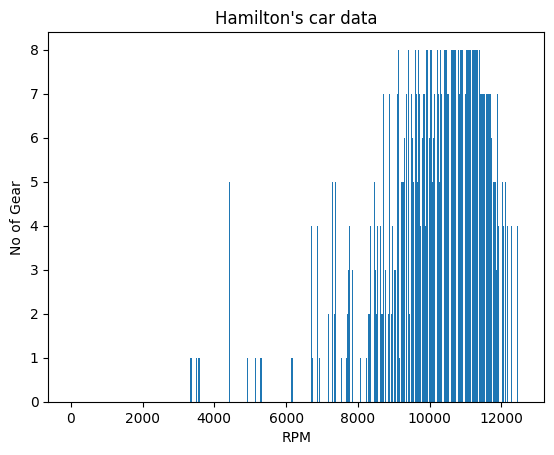

In [14]:
ham_car = car['44'] # getting the Hamilton's car (Key)
print(ham_car['RPM'], ham_car['nGear'])  # getting a particular column's data...

plt.bar(ham_car['RPM'], ham_car['nGear'])
plt.xlabel("RPM")
plt.ylabel("No of Gear")
plt.title("Hamilton's car data")
plt.show()

In [15]:
# To get the position of the Car... basically it gives the X and Y co-ordinates!!
pos = session.pos_data
ham_car_pos = pos['44']
print(ham_car_pos)

                         Date   Status       X       Y     Z Source  \
0     2026-03-08 03:08:04.681  OnTrack     0.0     0.0   0.0    pos   
1     2026-03-08 03:08:04.881  OnTrack     0.0     0.0   0.0    pos   
2     2026-03-08 03:08:05.141  OnTrack     0.0     0.0   0.0    pos   
3     2026-03-08 03:08:05.441  OnTrack     0.0     0.0   0.0    pos   
4     2026-03-08 03:08:05.741  OnTrack     0.0     0.0   0.0    pos   
...                       ...      ...     ...     ...   ...    ...   
32134 2026-03-08 05:28:36.181  OnTrack  6018.0  -776.0  94.0    pos   
32135 2026-03-08 05:28:36.461  OnTrack  6068.0  -834.0  94.0    pos   
32136 2026-03-08 05:28:36.621  OnTrack  6103.0  -876.0  94.0    pos   
32137 2026-03-08 05:28:36.861  OnTrack  6154.0  -941.0  95.0    pos   
32138 2026-03-08 05:28:37.221  OnTrack  6227.0 -1041.0  95.0    pos   

                        Time            SessionTime  
0     0 days 00:06:58.058000 0 days 00:06:58.058000  
1     0 days 00:06:58.258000 0 days 00:

In [16]:
# Getting the Circuit Information...
circuit = session.get_circuit_info()
cir_corners = circuit.corners
print(cir_corners)

rotation = circuit.rotation
print(rotation)

              X             Y  Number Letter       Angle     Distance
0  -3650.594482   1193.784180       1        -176.632730   353.883741
1  -3555.053223   1992.750244       2          -1.517007   436.700337
2  -7194.970215   7101.942383       3         162.258315  1082.289274
3  -5878.734375   7709.864746       4         -23.426263  1240.170991
4  -5870.662598   9676.805664       5         159.215959  1435.149386
5  -2280.641357  11861.559570       6          96.736266  1864.705500
6  -1296.382446  11398.008789       7        -104.065903  1987.203085
7    502.412537  10576.311523       8          39.145642  2157.206134
8   2838.843750    798.959839       9        -101.197334  3279.161824
9   3973.896484    855.019897      10          73.476771  3383.648575
10  7489.130859  -4851.345215      11         -15.779635  4087.765440
11  5020.217773  -5538.887695      12        -106.082895  4359.092824
12  3587.226562  -3634.000000      13          89.839297  4608.497211
13  2300.284180  -44

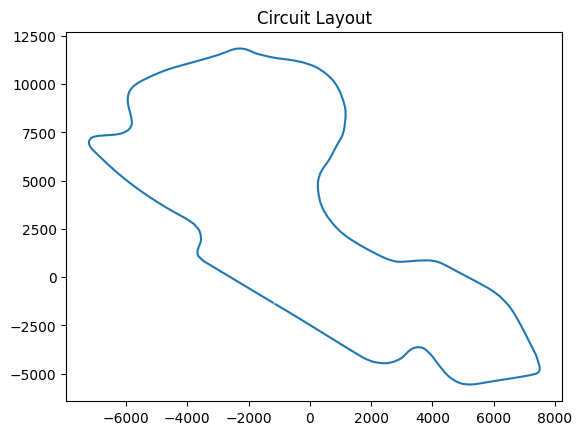

In [17]:
# To draw the circuit map!!
lap = session.laps.pick_fastest()
tel = lap.get_telemetry()

plt.plot(tel["X"], tel["Y"])
plt.title("Circuit Layout")
plt.show()

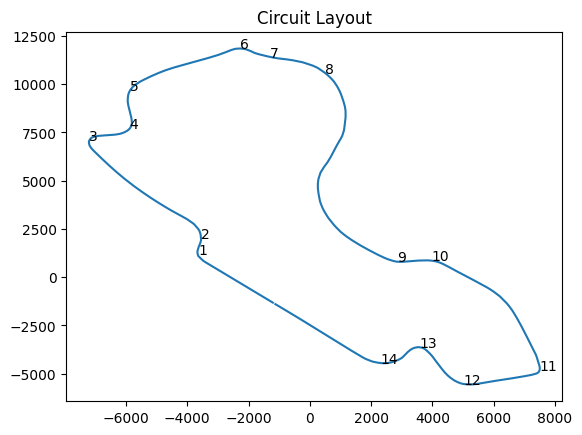

In [18]:
# To draw the Circuit map with corner labels...!
for _, corner in circuit.corners.iterrows():
    plt.text(corner['X'], corner['Y'], corner['Number'])

lap = session.laps.pick_fastest()
tel = lap.get_telemetry()

plt.plot(tel["X"], tel["Y"])
plt.title("Circuit Layout")
plt.show()

In [19]:
# Building the China Circuit Map!!

# Load the session
china_session = fastf1.get_session(2026, 'China', 'FP1')
china_session.load()

core           INFO 	Loading data for Chinese Grand Prix - Practice 1 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']


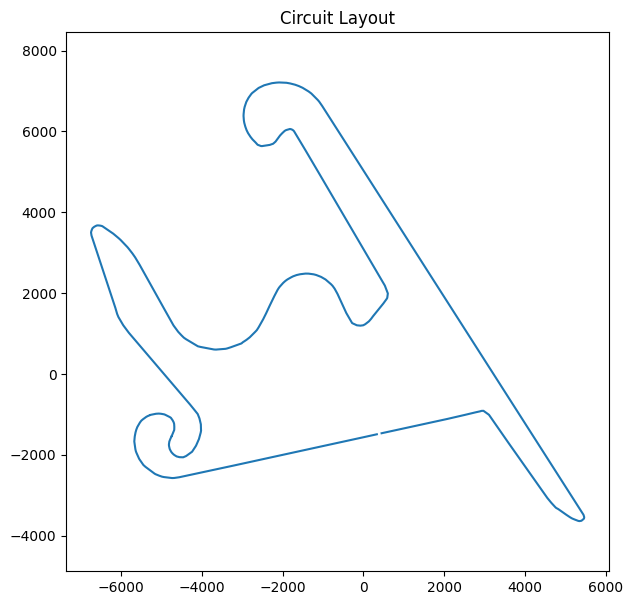

In [20]:
laps = china_session.laps.pick_fastest()
tele = laps.get_telemetry().sort_values(by="Distance")

plt.figure(figsize=(7,7))
plt.plot(tele["X"], tele["Y"])

plt.title("Circuit Layout")
plt.axis("equal")   # important
plt.show()

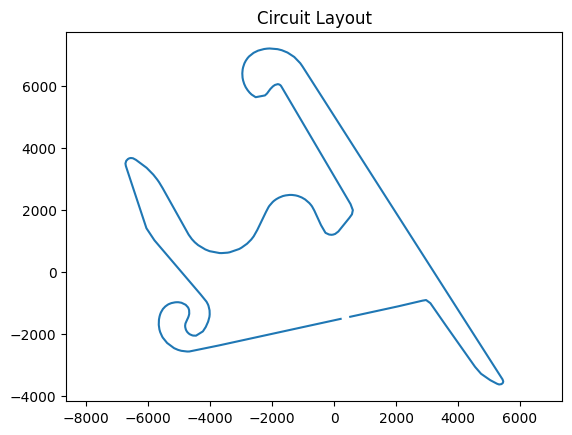

In [21]:
# Building the Circuit through pos data function from fastf1 api! This is more accurate!
laps = china_session.laps.pick_fastest()

pos = laps.get_pos_data()

x = pos['X']
y = pos['Y']

plt.plot(x,y)
plt.title("Circuit Layout")
plt.axis("equal")
plt.show()

In [22]:
# Plotting the Austrialian GP'26 Circuit showing the fast and slow areas of the circuit.

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

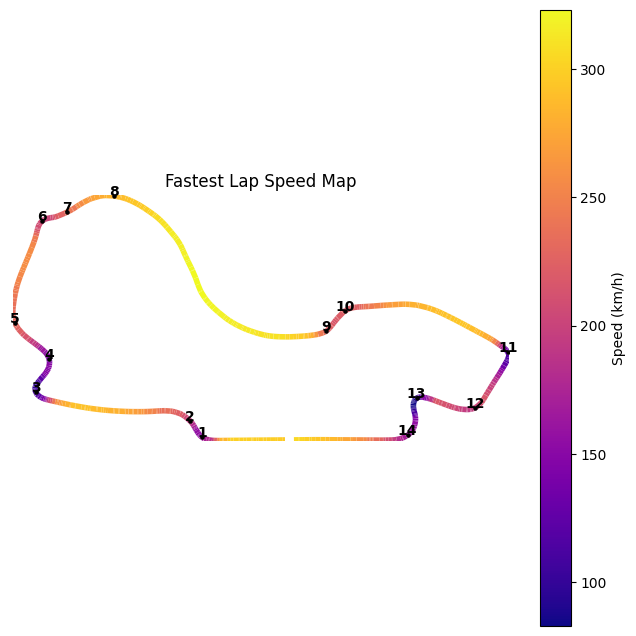

In [23]:
import fastf1
import fastf1.plotting
import numpy as np
import matplotlib.pyplot as plt # This only allows one color per line.
from matplotlib.collections import LineCollection # Allows you to draw a line that can have multiple colors along its length.
from matplotlib import cm # cm(color-maps); Provides color gradients, e.g., plasma or viridis. We need different shades to highlight areas.

# Enable plotting settings
fastf1.plotting.setup_mpl()

# Load session
session = fastf1.get_session(2026, "Australia", "R")
session.load()

# Get fastest lap
lap = session.laps.pick_fastest()

# Get telemetry and position data
car_data = lap.get_car_data().add_distance() # The .add_distance() converts the time-based data into the track-position data.
pos_data = lap.get_pos_data()

# Merge telemetry channels
telemetry = car_data.merge_channels(pos_data) # The .merge_channels() merges two dataframes according to the nearest possible timeframe. 
# So that we can plot the X,Y,Speed along the car's position on track.

# Remove rows with missing data
telemetry = telemetry.dropna(subset=["X", "Y", "Speed"]) # After merging,some rows may have missing values (NaN) because timestamps didn’t perfectly align.

# Extract arrays
x = telemetry["X"].to_numpy() #Converting Pandas into Numpy because Line Collection works best and efficiently on Numpy than Pandas.
y = telemetry["Y"].to_numpy()
speed = telemetry["Speed"].to_numpy()

# Get circuit info
circuit = session.get_circuit_info() 
angle = np.deg2rad(circuit.rotation) # To Make the CIRCUIT look North-Up!

# Rotate track
rot_x = x*np.cos(angle) - y*np.sin(angle) # X' = X cosQ - Y sinQ
rot_y = x*np.sin(angle) + y*np.cos(angle) # Y' = X sinQ + Y cosQ

# Create line segments
points = np.array([rot_x, rot_y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create colored line
norm = plt.Normalize(speed.min(), speed.max())
lc = LineCollection(segments, cmap=cm.plasma, norm=norm)
lc.set_array(speed)
lc.set_linewidth(4)

# Plot
fig, ax = plt.subplots(figsize=(8,8))
ax.add_collection(lc)

# Set axis limits because LineCollection does not automatically set axis limits (unlike plt.plot). Without this, the graph will break.
ax.set_xlim(rot_x.min(), rot_x.max()) 
ax.set_ylim(rot_y.min(), rot_y.max())

ax.set_aspect("equal")
ax.axis("off")

# Color bar
cbar = fig.colorbar(lc, ax=ax)
cbar.set_label("Speed (km/h)")

# Plot corner numbers
for _, corner in circuit.corners.iterrows():
    cx = corner['X']*np.cos(angle) - corner['Y']*np.sin(angle)
    cy = corner['X']*np.sin(angle) + corner['Y']*np.cos(angle)

    ax.text(cx, cy, str(corner['Number']),
            color="black", fontsize=10, ha="center", weight = "bold")
    ax.scatter(cx, cy, color='black', s=5, zorder=15)

plt.title("Fastest Lap Speed Map")
plt.show()

In [43]:
# Define the lap dataset used in the Model 1 analysis.
model1_laps = session.laps.copy()

print("Number of laps:", len(model1_laps))

Number of laps: 1007


In [25]:
print("\nAvailable columns:")
print(model1_laps.columns.tolist())



Available columns:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [44]:
print("\nFirst 5 rows:")
display(model1_laps.head())


First 5 rows:


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,...,True,McLaren,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True


In [27]:
for i, column in enumerate(model1_laps.columns, start=1):
    print(i, "→", column)

1 → Time
2 → Driver
3 → DriverNumber
4 → LapTime
5 → LapNumber
6 → Stint
7 → PitOutTime
8 → PitInTime
9 → Sector1Time
10 → Sector2Time
11 → Sector3Time
12 → Sector1SessionTime
13 → Sector2SessionTime
14 → Sector3SessionTime
15 → SpeedI1
16 → SpeedI2
17 → SpeedFL
18 → SpeedST
19 → IsPersonalBest
20 → Compound
21 → TyreLife
22 → FreshTyre
23 → Team
24 → LapStartTime
25 → LapStartDate
26 → TrackStatus
27 → Position
28 → Deleted
29 → DeletedReason
30 → FastF1Generated
31 → IsAccurate


In [28]:
norris  = session.laps.pick_drivers('NOR')
fastestLap = norris .pick_fastest()

print("Fastest lap:", fastestLap["LapNumber"])
print("Lap time:", fastestLap["LapTime"])


Fastest lap: 53.0
Lap time: 0 days 00:01:22.358000


In [29]:
norris  = session.laps.pick_drivers('NOR')

In [30]:
fastestLap = norris .pick_fastest()

In [31]:

telemetry = lap.get_telemetry()

In [32]:

print("Telemetry columns:")
print(telemetry.columns.tolist())

Telemetry columns:
['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']


In [33]:
model1 = session.laps[
    [
        "Driver",
        "LapNumber",
        "LapTime",
        "Compound",
        "TyreLife",
        "Stint",
        "TrackStatus",
        "Position",
        "Team"
    ]
].copy()

print("Model 1 dataset shape:", model1.shape)

display(model1.head(10))

Model 1 dataset shape: (1007, 9)


,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,TrackStatus,Position,Team
0,NOR,1.0,0 days 00:01:36.458000,MEDIUM,1.0,1.0,1,6.0,McLaren
1,NOR,2.0,0 days 00:01:27.344000,MEDIUM,2.0,1.0,1,6.0,McLaren
2,NOR,3.0,0 days 00:01:26.863000,MEDIUM,3.0,1.0,1,7.0,McLaren
3,NOR,4.0,0 days 00:01:25.857000,MEDIUM,4.0,1.0,1,7.0,McLaren
4,NOR,5.0,0 days 00:01:25.573000,MEDIUM,5.0,1.0,1,7.0,McLaren
5,NOR,6.0,0 days 00:01:25.036000,MEDIUM,6.0,1.0,1,7.0,McLaren
6,NOR,7.0,0 days 00:01:24.978000,MEDIUM,7.0,1.0,1,7.0,McLaren
7,NOR,8.0,0 days 00:01:25.299000,MEDIUM,8.0,1.0,1,7.0,McLaren
8,NOR,9.0,0 days 00:01:25.639000,MEDIUM,9.0,1.0,1,7.0,McLaren
9,NOR,10.0,0 days 00:01:25.295000,MEDIUM,10.0,1.0,1,7.0,McLaren


In [34]:
model1["LapTimeSeconds"] = model1["LapTime"].dt.total_seconds()

print("Lap time converted to seconds.")

display(
    model1[
        ["Driver", "LapNumber", "LapTime", "LapTimeSeconds", "Compound", "TyreLife"]
    ].head(10)
)

Lap time converted to seconds.


,Driver,LapNumber,LapTime,LapTimeSeconds,Compound,TyreLife
0,NOR,1.0,0 days 00:01:36.458000,96.458,MEDIUM,1.0
1,NOR,2.0,0 days 00:01:27.344000,87.344,MEDIUM,2.0
2,NOR,3.0,0 days 00:01:26.863000,86.863,MEDIUM,3.0
3,NOR,4.0,0 days 00:01:25.857000,85.857,MEDIUM,4.0
4,NOR,5.0,0 days 00:01:25.573000,85.573,MEDIUM,5.0
5,NOR,6.0,0 days 00:01:25.036000,85.036,MEDIUM,6.0
6,NOR,7.0,0 days 00:01:24.978000,84.978,MEDIUM,7.0
7,NOR,8.0,0 days 00:01:25.299000,85.299,MEDIUM,8.0
8,NOR,9.0,0 days 00:01:25.639000,85.639,MEDIUM,9.0
9,NOR,10.0,0 days 00:01:25.295000,85.295,MEDIUM,10.0


In [35]:
model1["LapTimeSeconds"] = model1["LapTime"].dt.total_seconds()

print(model1.columns.tolist())

['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'TrackStatus', 'Position', 'Team', 'LapTimeSeconds']


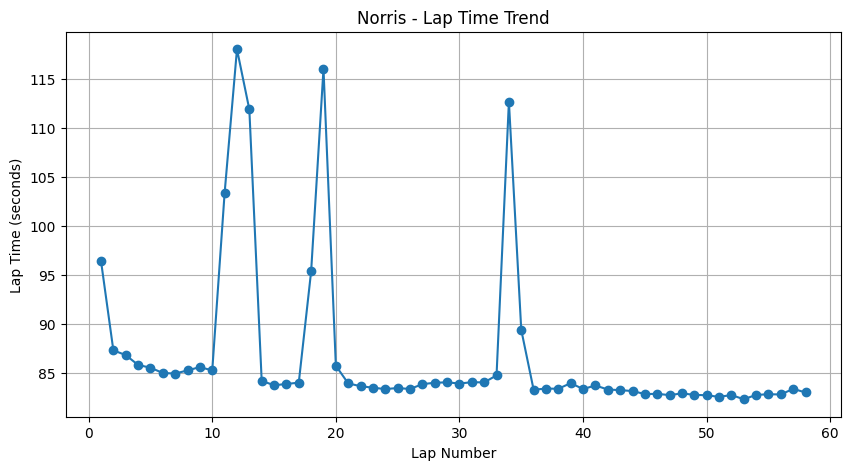

In [36]:
import matplotlib.pyplot as plt

nor = model1[model1["Driver"] == "NOR"].dropna(
    subset=["LapTimeSeconds"]
)

plt.figure(figsize=(10, 5))

plt.plot(
    nor["LapNumber"],
    nor["LapTimeSeconds"],
    marker="o"
)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Norris - Lap Time Trend")

plt.grid(True)
plt.show()

In [37]:
nor = model1[model1["Driver"] == "NOR"]

print("Number of Norris rows:", len(nor))
print("Lap numbers available:")
print(nor["LapNumber"].tolist())


Number of Norris rows: 58
Lap numbers available:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0]


In [38]:
print("Norris Tyre Information:")

display(
    nor[
        ["LapNumber", "LapTimeSeconds", "Compound", "TyreLife", "Stint"]
    ].head(20)
)

Norris Tyre Information:


,LapNumber,LapTimeSeconds,Compound,TyreLife,Stint
0,1.0,96.458,MEDIUM,1.0,1.0
1,2.0,87.344,MEDIUM,2.0,1.0
2,3.0,86.863,MEDIUM,3.0,1.0
3,4.0,85.857,MEDIUM,4.0,1.0
4,5.0,85.573,MEDIUM,5.0,1.0
5,6.0,85.036,MEDIUM,6.0,1.0
6,7.0,84.978,MEDIUM,7.0,1.0
7,8.0,85.299,MEDIUM,8.0,1.0
8,9.0,85.639,MEDIUM,9.0,1.0
9,10.0,85.295,MEDIUM,10.0,1.0


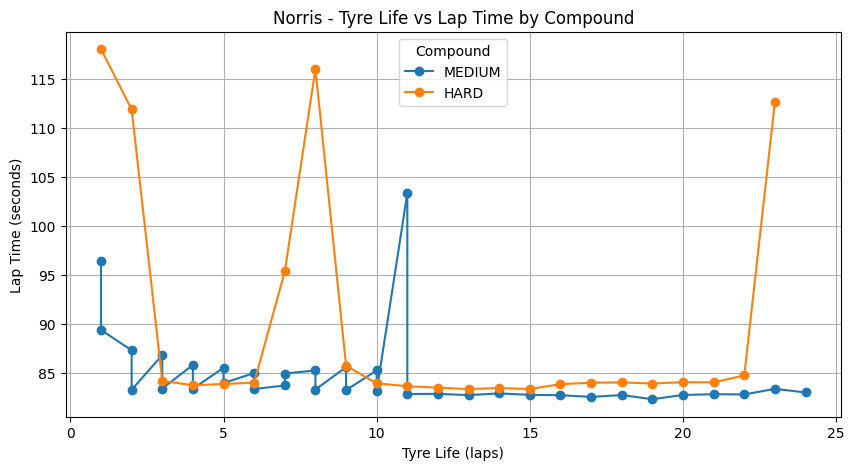

In [39]:
import matplotlib.pyplot as plt

nor = model1[
    model1["Driver"] == "NOR"
].dropna(
    subset=["LapTimeSeconds", "TyreLife", "Compound"]
)

plt.figure(figsize=(10, 5))

for compound in nor["Compound"].unique():
    data = nor[nor["Compound"] == compound].sort_values("TyreLife")

    plt.plot(
        data["TyreLife"],
        data["LapTimeSeconds"],
        marker="o",
        label=compound
    )

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Norris - Tyre Life vs Lap Time by Compound")
plt.legend(title="Compound")
plt.grid(True)
plt.show()

In [40]:
print("Norris Tyre Compounds:")
print(nor["Compound"].value_counts(dropna=False))

print("\nTyre Life statistics:")
print(nor["TyreLife"].describe())

print("\nStints:")
print(nor["Stint"].value_counts(dropna=False))

Norris Tyre Compounds:
Compound
MEDIUM    35
HARD      23
Name: count, dtype: int64

Tyre Life statistics:
count    58.000000
mean     11.068966
std       6.784560
min       1.000000
25%       5.250000
50%      10.000000
75%      16.750000
max      24.000000
Name: TyreLife, dtype: float64

Stints:
Stint
3.0    24
2.0    23
1.0    11
Name: count, dtype: int64


In [41]:
print("Norris Stint-wise Analysis")

display(
    nor.groupby(["Stint", "Compound"]).agg(
        Laps=("LapNumber", "count"),
        AvgLapTime=("LapTimeSeconds", "mean"),
        BestLapTime=("LapTimeSeconds", "min"),
        MaxTyreLife=("TyreLife", "max")
    ).reset_index()
)

Norris Stint-wise Analysis


,Stint,Compound,Laps,AvgLapTime,BestLapTime,MaxTyreLife
0,1.0,MEDIUM,11,88.339364,84.978,11.0
1,2.0,HARD,23,89.843261,83.394,23.0
2,3.0,MEDIUM,24,83.350583,82.358,24.0


In [42]:
import pandas as pd
import numpy as np

# Norris data
nor = model1[
    model1["Driver"] == "NOR"
].copy()

# Sort by lap number
nor = nor.sort_values("LapNumber").reset_index(drop=True)

# Previous and next lap times
nor["PreviousLap"] = nor["LapTimeSeconds"].shift(1)
nor["NextLap"] = nor["LapTimeSeconds"].shift(-1)

# Local average of surrounding laps
nor["NeighbourAverage"] = (
    nor["PreviousLap"] + nor["NextLap"]
) / 2

# Difference from surrounding laps
nor["LapDifference"] = (
    nor["LapTimeSeconds"] - nor["NeighbourAverage"]
)

# Show most unusual laps
unusual_laps = nor[
    ["LapNumber",
     "LapTimeSeconds",
     "PreviousLap",
     "NextLap",
     "LapDifference",
     "Compound",
     "TyreLife",
     "Stint",
     "TrackStatus"]
].dropna()

unusual_laps = unusual_laps.sort_values(
    "LapDifference",
    key=abs,
    ascending=False
)

print("Most unusual Norris laps:")
display(unusual_laps.head(10))


Most unusual Norris laps:


,LapNumber,LapTimeSeconds,PreviousLap,NextLap,LapDifference,Compound,TyreLife,Stint,TrackStatus
33,34.0,112.732,84.790,89.434,25.6200,HARD,23.0,2.0,167
18,19.0,116.070,95.404,85.774,25.4810,HARD,8.0,2.0,67
19,20.0,85.774,116.070,83.972,-14.2470,HARD,9.0,2.0,71
13,14.0,84.233,111.932,83.784,-13.6250,HARD,3.0,2.0,1
32,33.0,84.790,84.075,112.732,-13.6135,HARD,22.0,2.0,1
12,13.0,111.932,118.075,84.233,10.7780,HARD,2.0,2.0,671
11,12.0,118.075,103.391,111.932,10.4135,HARD,1.0,2.0,6
9,10.0,85.295,85.639,103.391,-9.2200,MEDIUM,10.0,1.0,1
34,35.0,89.434,112.732,83.324,-8.5940,MEDIUM,1.0,3.0,1
16,17.0,84.053,83.912,95.404,-5.6050,HARD,6.0,2.0,1
